total data after cleaning
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.686763      72.405184      29.153420  155.548223   
std       3.369578   30.435949      12.096346       8.790942   85.021108   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.202592      29.153420  155.548223   
75%       6.000000  140.250000      80.000000      32.000000  155.548223   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.457464                  0.471876   33.240885    0.348958  
std      6.875151                  0.331329   11.760232    0.476951  
min     1

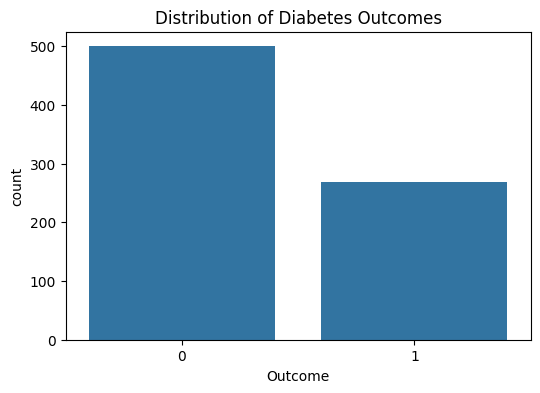

✅ done


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/diabetes.csv') 


cols_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_fix:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].mean())


print("total data after cleaning")
print(df.describe())


plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Diabetes Outcomes')
plt.show()


df.to_csv('cleaned_diabetes.csv', index=False)
print("✅ done")

In [4]:
# 1. Define columns where zero values are logically incorrect
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Replace 0 with NaN (Not a Number) to identify missing data
df[missing_cols] = df[missing_cols].replace(0, np.nan)

# 3. Check the count of missing values in each column
print("Count of missing values per column:")
print(df.isnull().sum())

# 4. Handle missing values using Imputation (Mean/Median)
# Using Mean for normally distributed data
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

# Using Median for skewed data (SkinThickness and Insulin often have outliers)
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())

# 5. Verify that there are no more missing values
print("\n✅ Missing values handled successfully!")
print(df.isnull().sum())

Count of missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ Missing values handled successfully!
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate features (X) and target (y)
# 'Outcome' is what we want to predict
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 2. Split data into training and testing sets (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the four models as required by the project
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# 4. Train and evaluate each model
print("--- Model Performance Comparison ---")
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# 5. Show detailed report for the best performing model
best_model_name = max(results, key=results.get)
print(f"\n⭐ Best Model: {best_model_name}")
print(f"Classification Report for {best_model_name}:")
print(classification_report(y_test, models[best_model_name].predict(X_test)))

--- Model Performance Comparison ---
Logistic Regression Accuracy: 0.7532
Random Forest Accuracy: 0.7532
Support Vector Machine Accuracy: 0.7597
K-Nearest Neighbors Accuracy: 0.6494

⭐ Best Model: Support Vector Machine
Classification Report for Support Vector Machine:
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        99
           1       0.71      0.55      0.62        55

    accuracy                           0.76       154
   macro avg       0.75      0.71      0.72       154
weighted avg       0.75      0.76      0.75       154



In [6]:
import pickle
import os

# Create the models directory if it doesn't exist
if not os.path.exists('../models'):
    os.makedirs('../models')

# Save the best model (Support Vector Machine)
# Note: We save the model as 'diabetes_model.pkl' to use it in the app
with open('../models/diabetes_model.pkl', 'wb') as file:
    pickle.dump(models["Support Vector Machine"], file)

print("✅ Model saved successfully in: models/diabetes_model.pkl")

✅ Model saved successfully in: models/diabetes_model.pkl


--- Step 1: Loading Data ---
✅ Dataset loaded successfully!
Shape: 768 rows, 9 columns

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- Step 2: Preprocessing - Handling Missing Values ---
Missing values count per column (zeros replaced with NaN):
Pregnancies                   0
Glucose                       5
BloodPressure        

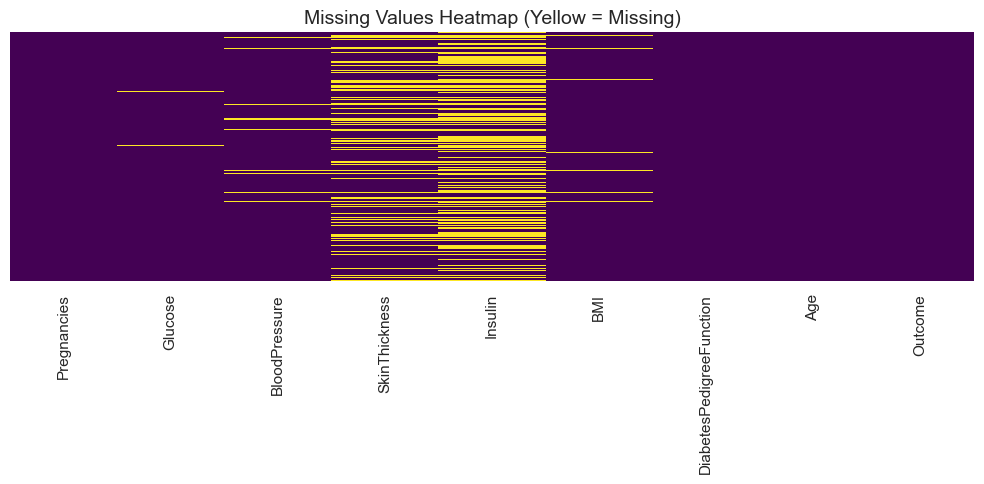


Imputing missing values with column means...
✅ Missing values handled.

--- Step 3: Exploratory Data Analysis (EDA) ---


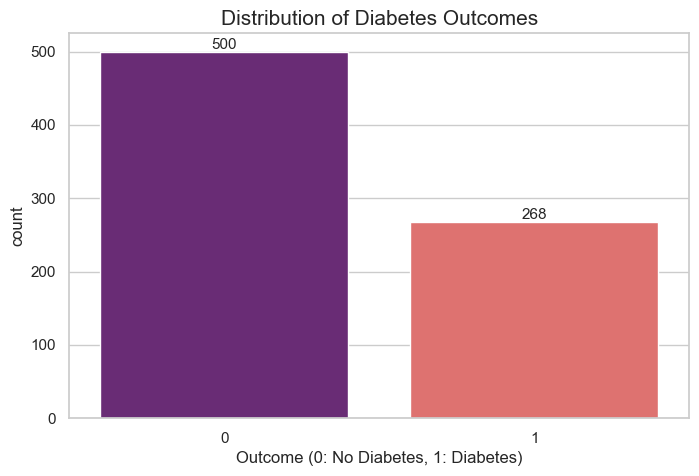

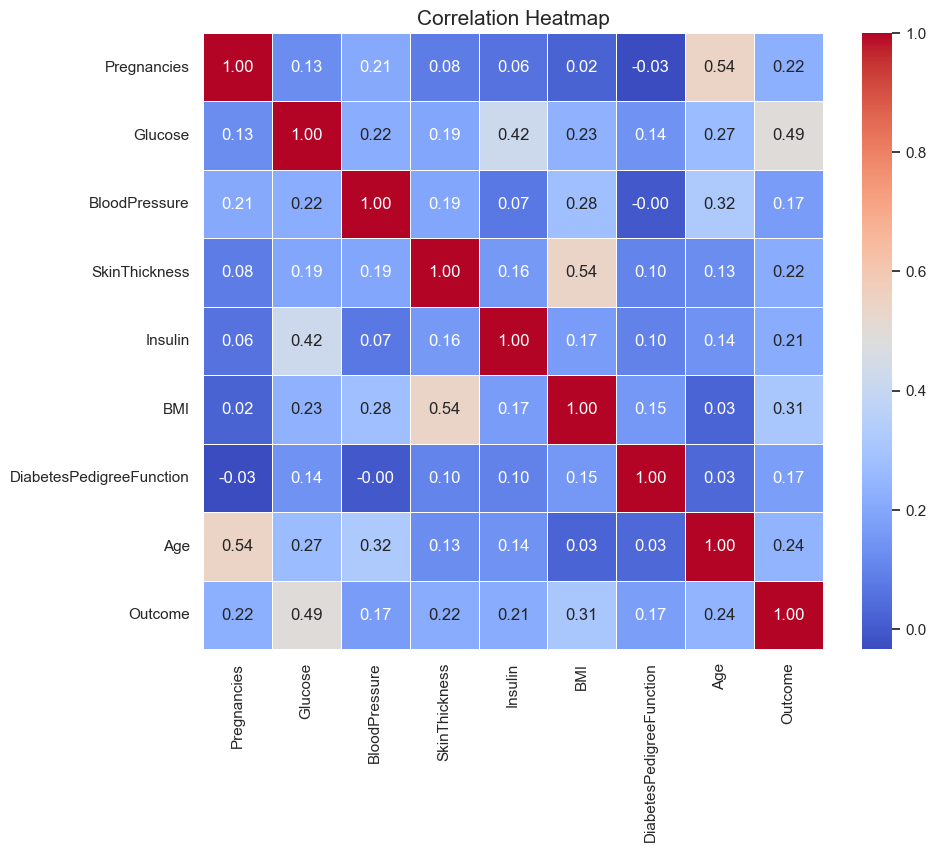


--- Step 4: Model Development & Evaluation ---
Data split: 614 training, 154 testing samples.

Training and evaluating models...
Logistic Regression Accuracy: 0.7532
Random Forest Accuracy: 0.7532
Support Vector Machine Accuracy: 0.7532
K-Nearest Neighbors Accuracy: 0.7468


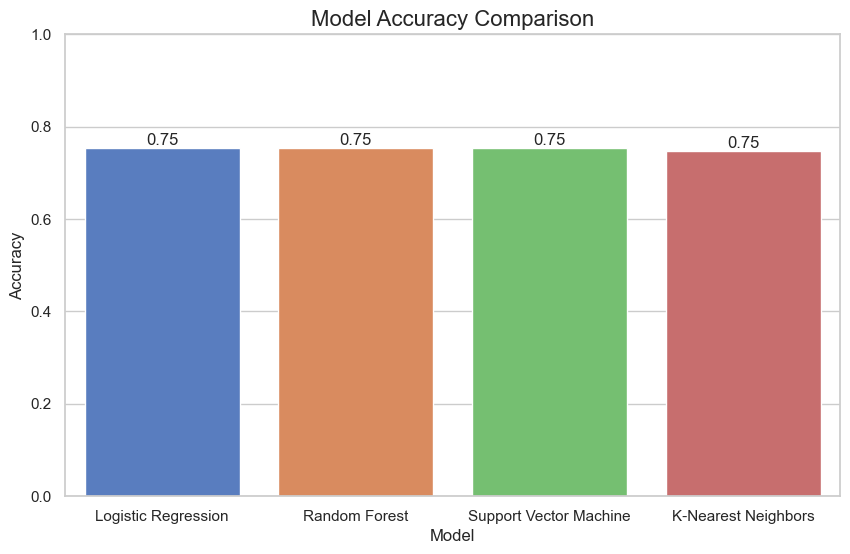


⭐ Best Performing Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



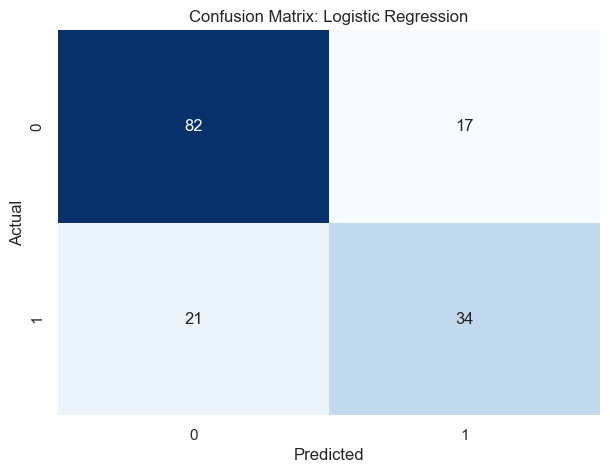


--- Step 5: Saving Cleaned Data & Best Model ---
💾 Cleaned data and best pipeline saved successfully!

Process finished successfully!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Configure inline plotting for notebooks
%matplotlib inline
# Set a stylish seaborn theme for professional-looking plots
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================================
# 1. DATA LOADING & INITIAL EXPLORATION
# ==========================================================
print("--- Step 1: Loading Data ---")
try:
    # Load the dataset
    df = pd.read_csv('../data/diabetes.csv')
    print("✅ Dataset loaded successfully!")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("\nFirst 5 rows:")
    print(df.head())
except FileNotFoundError:
    print("❌ Error: 'diabetes.csv' not found. Please ensure it's in the '../data/' directory.")
    # Create dummy data if file is missing just so the script structure is visible
    df = pd.DataFrame() 

# ==========================================================
# 2. DATA PREPROCESSING (HANDLING MISSING VALUES)
# ==========================================================
print("\n--- Step 2: Preprocessing - Handling Missing Values ---")

# Columns where 0 is logically impossible
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

print("Missing values count per column (zeros replaced with NaN):")
print(df.isnull().sum())

# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=14)
plt.tight_layout()
plt.show()

# Impute missing values using explicit assignment to avoid ChainedAssignmentError
print("\nImputing missing values with column means...")
for col in columns_with_zeros:
    df[col] = df[col].fillna(df[col].mean())

print("✅ Missing values handled.")

# ==========================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================
print("\n--- Step 3: Exploratory Data Analysis (EDA) ---")

# 3.1 Outcome Distribution - Fixed for Seaborn v0.14+
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Outcome', hue='Outcome', data=df, palette='magma', legend=False)
plt.title('Distribution of Diabetes Outcomes', fontsize=15)
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, xytext=(0, 5), textcoords='offset points')
plt.show()

# 3.2 Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap', fontsize=15)
plt.show()

# ==========================================================
# 4. MODEL DEVELOPMENT & EVALUATION
# ==========================================================
print("\n--- Step 4: Model Development & Evaluation ---")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data split: {X_train.shape[0]} training, {X_test.shape[0]} testing samples.")

# Define Pipelines to handle Scaling and Imputation automatically
models_config = {
    "Logistic Regression": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "Support Vector Machine": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', SVC(probability=True))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier())
    ])
}

results_list = []
trained_pipelines = {}

print("\nTraining and evaluating models...")
for name, pipeline in models_config.items():
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_list.append({"Model": name, "Accuracy": acc})
    print(f"{name} Accuracy: {acc:.4f}")

# Create results DataFrame for plotting
results_df = pd.DataFrame(results_list).sort_values('Accuracy', ascending=False)

# 4.5 Visualizing Performance
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Model', y='Accuracy', data=results_df, hue='Model', legend=False)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylim(0, 1)

best_model_name = results_df.iloc[0]['Model']
best_model_acc = results_df.iloc[0]['Accuracy']

# Add labels on top of bars
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)
plt.show()

# 4.6 Detailed Report for the Best Model
print(f"\n⭐ Best Performing Model: {best_model_name}")
print(classification_report(y_test, trained_pipelines[best_model_name].predict(X_test)))

# 4.7 Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, trained_pipelines[best_model_name].predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ==========================================================
# 5. SAVING OUTPUTS
# ==========================================================
print("\n--- Step 5: Saving Cleaned Data & Best Model ---")
try:
    df.to_csv('cleaned_diabetes_data.csv', index=False)
    with open('best_diabetes_pipeline.pkl', 'wb') as f:
        pickle.dump(trained_pipelines[best_model_name], f)
    print("💾 Cleaned data and best pipeline saved successfully!")
except Exception as e:
    print(f"⚠️ Saving error: {e}")

print("\nProcess finished successfully!")